# Tweede Kamer Speech Pipeline
End-to-end pipeline: scrape → parse → join → save

## 1. Imports

In [60]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET
import re
from pathlib import Path

## 2. Base URL

In [61]:
BASE = "https://gegevensmagazijn.tweedekamer.nl/OData/v4/2.0" 

## 3. Fetch Verslag metadata

In [62]:
def fetch_all_verslagen():
    rows = []
    skip = 0
    while True:
        params = {"$filter": "Verwijderd eq false", "$select": "Id,Soort,Status,Vergadering_Id", "$top": 250, "$skip": skip}
        r = requests.get(f"{BASE}/Verslag", params=params)
        r.raise_for_status()
        batch = r.json().get("value", [])
        if not batch:
            break
        rows.extend(batch)
        skip += 250
    return pd.DataFrame(rows)

verslag_df = fetch_all_verslagen()
print(len(verslag_df))

22654


## 4. Download XML files

In [63]:
def download_xmls(verslag_df, out_dir="verslagen_xml", limit=1000):
    out = Path(out_dir)
    out.mkdir(exist_ok=True)
    for i, row in verslag_df.iterrows():
        if i >= limit:
            break
        vid = row["Id"]
        url = f"{BASE}/Verslag({vid})/resource"
        r = requests.get(url)
        r.raise_for_status()
        (out / f"{vid}.xml").write_bytes(r.content)

if not list(Path("verslagen_xml").glob("*.xml")):
    download_xmls(verslag_df, limit=1000)

## 5. XML Parsing

In [64]:
NS = {"tk": "http://www.tweedekamer.nl/ggm/vergaderverslag/v1.0"}

def clean_text(text):
    if not text:
        return ""
    return re.sub(r"\s+", " ", text).strip()

def extract_text_from_node(node):
    if node is None:
        return ""
    parts = []
    for t in node.itertext():
        t = clean_text(t)
        if t:
            parts.append(t)
    return clean_text(" ".join(parts))

def parse_speeches_from_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    rows = []

    vergadering = root.find("tk:vergadering", NS)
    vergadering_id = vergadering.attrib.get("objectid", "") if vergadering is not None else ""
    vergadering_titel = vergadering.findtext("tk:titel", default="", namespaces=NS) if vergadering is not None else ""
    vergadering_datum = vergadering.findtext("tk:datum", default="", namespaces=NS) if vergadering is not None else ""

    for activiteit in root.findall(".//tk:activiteit", NS):
        activiteit_id = activiteit.attrib.get("objectid", "")
        activiteit_soort = activiteit.attrib.get("soort", "")
        activiteit_titel = activiteit.findtext("tk:titel", default="", namespaces=NS)
        activiteit_onderwerp = activiteit.findtext("tk:onderwerp", default="", namespaces=NS)

        for activiteitdeel in activiteit.findall(".//tk:activiteitdeel[@soort='Spreekbeurt']", NS):
            spreekbeurt_id = activiteitdeel.attrib.get("objectid", "")

            for woordvoerder in activiteitdeel.findall(".//tk:woordvoerder", NS):
                spreker = woordvoerder.find("tk:spreker", NS)

                speaker_id = spreker.attrib.get("objectid", "") if spreker is not None else ""
                speaker_name = spreker.findtext("tk:weergavenaam", default="", namespaces=NS) if spreker is not None else ""
                speaker_party = spreker.findtext("tk:fractie", default="", namespaces=NS) if spreker is not None else ""
                speaker_role = spreker.findtext("tk:functie", default="", namespaces=NS) if spreker is not None else ""

                speech_begin = woordvoerder.findtext("tk:markeertijdbegin", default="", namespaces=NS)
                speech_end = woordvoerder.findtext("tk:markeertijdeind", default="", namespaces=NS)
                is_voorzitter = woordvoerder.findtext("tk:isvoorzitter", default="", namespaces=NS)

                tekst_node = woordvoerder.find("tk:tekst", NS)
                speech_text = extract_text_from_node(tekst_node)

                if speech_text:
                    rows.append({
                        "speech_id": spreekbeurt_id,
                        "vergadering_id": vergadering_id,
                        "vergadering_titel": vergadering_titel,
                        "vergadering_datum": vergadering_datum,
                        "activiteit_id": activiteit_id,
                        "activiteit_soort": activiteit_soort,
                        "activiteit_titel": activiteit_titel,
                        "activiteit_onderwerp": activiteit_onderwerp,
                        "speaker_id": speaker_id,
                        "speaker_name": speaker_name,
                        "speaker_party": speaker_party,
                        "speaker_role": speaker_role,
                        "speech_begin": speech_begin,
                        "speech_end": speech_end,
                        "is_voorzitter": is_voorzitter,
                        "speech_text": speech_text,
                        "source": str(xml_path)
                    })

    return pd.DataFrame(rows)

In [65]:
def parse_all_xmls(xml_dir="verslagen_xml"):
    frames = []

    for xml_file in Path(xml_dir).glob("*.xml"):
        try:
            df = parse_speeches_from_xml(xml_file)
            if not df.empty:
                frames.append(df)
        except Exception as e:
            print(f"Error in {xml_file}: {e}")

    if frames:
        return pd.concat(frames, ignore_index=True)
    return pd.DataFrame()

speeches_df = parse_all_xmls("verslagen_xml")
print(speeches_df.columns.tolist())
print(speeches_df.shape)
speeches_df.head()

['speech_id', 'vergadering_id', 'vergadering_titel', 'vergadering_datum', 'activiteit_id', 'activiteit_soort', 'activiteit_titel', 'activiteit_onderwerp', 'speaker_id', 'speaker_name', 'speaker_party', 'speaker_role', 'speech_begin', 'speech_end', 'is_voorzitter', 'speech_text', 'source']
(148142, 17)


,speech_id,vergadering_id,vergadering_titel,vergadering_datum,activiteit_id,activiteit_soort,activiteit_titel,activiteit_onderwerp,speaker_id,speaker_name,speaker_party,speaker_role,speech_begin,speech_end,is_voorzitter,speech_text,source
0,53a576a3-68cd-4b5a-b232-824ddf537fa0,84603186-63f8-4f45-9176-4d28e9715c9b,"62e vergadering, woensdag 11 maart 2015",2015-03-11T00:00:00,f5cbb242-3e8d-4ddb-8d24-43747db8ea0b,Plenair debat,Wegverkeer en verkeersveiligheid,Wegverkeer en verkeersveiligheid (AO d.d. 12/02),938a6327-cef0-42ad-ae89-6f6e72f4be49,Elias,VVD,Lid Tweede Kamer,2015-03-11T10:47:05,2015-03-11T10:47:24,true,De voorzitter : Ik heet van harte welkom de mi...,verslagen_xml\00638944-798e-4da2-917c-0a7a030f...
1,cc0f1d7d-e378-4c40-b7f5-17a3f03d22f5,84603186-63f8-4f45-9176-4d28e9715c9b,"62e vergadering, woensdag 11 maart 2015",2015-03-11T00:00:00,f5cbb242-3e8d-4ddb-8d24-43747db8ea0b,Plenair debat,Wegverkeer en verkeersveiligheid,Wegverkeer en verkeersveiligheid (AO d.d. 12/02),3d7d7efa-acf4-4c1a-b875-8653079409f5,M.J.F. van Helvert,CDA,Lid Tweede Kamer,2015-03-11T10:47:24,2015-03-11T10:48:34,false,De heer Van Helvert (CDA): Voorzitter. Ik wil ...,verslagen_xml\00638944-798e-4da2-917c-0a7a030f...
2,cc0f1d7d-e378-4c40-b7f5-17a3f03d22f5,84603186-63f8-4f45-9176-4d28e9715c9b,"62e vergadering, woensdag 11 maart 2015",2015-03-11T00:00:00,f5cbb242-3e8d-4ddb-8d24-43747db8ea0b,Plenair debat,Wegverkeer en verkeersveiligheid,Wegverkeer en verkeersveiligheid (AO d.d. 12/02),3d7d7efa-acf4-4c1a-b875-8653079409f5,M.J.F. van Helvert,CDA,Lid Tweede Kamer,2015-03-11T10:48:34,2015-03-11T10:49:17,false,De heer Van Helvert (CDA): De tweede motie gaa...,verslagen_xml\00638944-798e-4da2-917c-0a7a030f...
3,cc0f1d7d-e378-4c40-b7f5-17a3f03d22f5,84603186-63f8-4f45-9176-4d28e9715c9b,"62e vergadering, woensdag 11 maart 2015",2015-03-11T00:00:00,f5cbb242-3e8d-4ddb-8d24-43747db8ea0b,Plenair debat,Wegverkeer en verkeersveiligheid,Wegverkeer en verkeersveiligheid (AO d.d. 12/02),3d7d7efa-acf4-4c1a-b875-8653079409f5,M.J.F. van Helvert,CDA,Lid Tweede Kamer,2015-03-11T10:49:17,2015-03-11T10:49:26,false,De heer Van Helvert (CDA): Als het gaat om de ...,verslagen_xml\00638944-798e-4da2-917c-0a7a030f...
4,cc0f1d7d-e378-4c40-b7f5-17a3f03d22f5,84603186-63f8-4f45-9176-4d28e9715c9b,"62e vergadering, woensdag 11 maart 2015",2015-03-11T00:00:00,f5cbb242-3e8d-4ddb-8d24-43747db8ea0b,Plenair debat,Wegverkeer en verkeersveiligheid,Wegverkeer en verkeersveiligheid (AO d.d. 12/02),3d7d7efa-acf4-4c1a-b875-8653079409f5,M.J.F. van Helvert,CDA,Lid Tweede Kamer,2015-03-11T10:49:27,2015-03-11T10:49:36,false,De heer Van Helvert (CDA): Jazeker. Het is een...,verslagen_xml\00638944-798e-4da2-917c-0a7a030f...


In [66]:
speeches_df = parse_all_xmls("verslagen_xml")
print(speeches_df.shape)
speeches_df.to_csv("speeches_raw.csv", index=False)

(148142, 17)


## 6. Fetch Metadata (Agendapunt, Activiteit, Besluit)

In [67]:
import requests
import pandas as pd
import time

def fetch_all(entity, select_cols=None, filter_query=None, max_retries=5, sleep_seconds=1):
    rows = []
    skip = 0

    while True:
        params = {"$top": 250, "$skip": skip}
        if select_cols:
            params["$select"] = select_cols
        if filter_query:
            params["$filter"] = filter_query

        success = False
        for attempt in range(max_retries):
            try:
                print(f"{entity}: fetching rows {skip} to {skip + 249} (attempt {attempt + 1})")
                r = requests.get(f"{BASE}/{entity}", params=params, timeout=60)
                r.raise_for_status()
                batch = r.json().get("value", [])
                success = True
                break
            except requests.exceptions.HTTPError as e:
                print(f"HTTP error: {e}")
                if attempt < max_retries - 1:
                    wait = sleep_seconds * (2 ** attempt)
                    print(f"Retrying in {wait} seconds...")
                    time.sleep(wait)
                else:
                    raise
            except requests.exceptions.RequestException as e:
                print(f"Request error: {e}")
                if attempt < max_retries - 1:
                    wait = sleep_seconds * (2 ** attempt)
                    print(f"Retrying in {wait} seconds...")
                    time.sleep(wait)
                else:
                    raise

        if not success:
            break

        if not batch:
            break

        rows.extend(batch)
        skip += 250

        time.sleep(0.5)

    return pd.DataFrame(rows)

In [87]:
act = fetch_all(
    "Activiteit",
    "Id,Soort,Onderwerp,Datum,Aanvangstijd,Eindtijd,Status,Vergaderjaar,Kamer",
    "Verwijderd eq false"
)
act.to_csv("activiteit.csv", index=False)
print(act.shape)
act.head()

Activiteit: fetching rows 0 to 249 (attempt 1)
Activiteit: fetching rows 250 to 499 (attempt 1)
Activiteit: fetching rows 500 to 749 (attempt 1)
Activiteit: fetching rows 750 to 999 (attempt 1)
Activiteit: fetching rows 1000 to 1249 (attempt 1)
Activiteit: fetching rows 1250 to 1499 (attempt 1)
Activiteit: fetching rows 1500 to 1749 (attempt 1)
Activiteit: fetching rows 1750 to 1999 (attempt 1)
Activiteit: fetching rows 2000 to 2249 (attempt 1)
Activiteit: fetching rows 2250 to 2499 (attempt 1)
Activiteit: fetching rows 2500 to 2749 (attempt 1)
Activiteit: fetching rows 2750 to 2999 (attempt 1)
Activiteit: fetching rows 3000 to 3249 (attempt 1)
Activiteit: fetching rows 3250 to 3499 (attempt 1)
Activiteit: fetching rows 3500 to 3749 (attempt 1)
Activiteit: fetching rows 3750 to 3999 (attempt 1)
Activiteit: fetching rows 4000 to 4249 (attempt 1)
Activiteit: fetching rows 4250 to 4499 (attempt 1)
Activiteit: fetching rows 4500 to 4749 (attempt 1)
Activiteit: fetching rows 4750 to 4999 (a

,Id,Soort,Onderwerp,Datum,Aanvangstijd,Eindtijd,Status,Vergaderjaar,Kamer
0,1573af00-ec77-4d11-ab11-0000f5f846b5,Inbreng verslag (wetsvoorstel),Wet vrij en veilig onderwijs,2025-09-11T10:00:00+02:00,2025-09-11T10:00:00+02:00,2025-09-11T10:00:00+02:00,Uitgevoerd,2024-2025,Tweede Kamer
1,b7cf7dfc-1f46-4351-b2a5-000236b07ffa,Procedurevergadering,Procedures en brieven,2019-11-07T13:30:00+01:00,2019-11-07T13:30:00+01:00,2019-11-07T14:30:00+01:00,Uitgevoerd,2018-2019,Tweede Kamer
2,4e9a6798-b365-48b1-bf81-0002b17c9820,Plenair debat (debat),Debat over ProRail (derde termijn),2015-11-09T00:00:00+01:00,None,None,Geannuleerd,2014-2015,Tweede Kamer
3,ed23ae00-69bc-423b-b10e-0002e034f69f,Stemmingen,Stemmingen,2016-05-31T15:00:00+02:00,2016-05-31T15:00:00+02:00,2016-05-31T23:59:00+02:00,Uitgevoerd,2015-2016,Tweede Kamer
4,e7fa78c5-bae3-4b85-9c5e-0003e4d13cde,Stemmingen,Aansluitend aan de Regeling van werkzaamheden:...,2014-06-11T13:55:00+02:00,2014-06-11T13:55:00+02:00,2014-06-11T23:59:00+02:00,Uitgevoerd,2013-2014,Tweede Kamer


In [69]:
import requests
import pandas as pd
import time
from pathlib import Path

def fetch_all_checkpoint(entity, select_cols=None, filter_query=None, save_every=5000):
    rows = []
    skip = 0
    out_file = Path(f"{entity.lower()}_checkpoint.csv")

    while True:
        params = {"$top": 250, "$skip": skip}
        if select_cols:
            params["$select"] = select_cols
        if filter_query:
            params["$filter"] = filter_query

        for attempt in range(5):
            try:
                print(f"{entity}: fetching rows {skip} to {skip + 249}")
                r = requests.get(f"{BASE}/{entity}", params=params, timeout=60)
                r.raise_for_status()
                batch = r.json().get("value", [])
                break
            except Exception as e:
                print(f"Error: {e}")
                if attempt < 4:
                    wait = 2 ** attempt
                    print(f"Retrying in {wait} seconds...")
                    time.sleep(wait)
                else:
                    raise

        if not batch:
            break

        rows.extend(batch)
        skip += 250

        if len(rows) % save_every == 0:
            pd.DataFrame(rows).to_csv(out_file, index=False)
            print(f"Checkpoint saved: {out_file}")

        time.sleep(0.5)

    df = pd.DataFrame(rows)
    df.to_csv(f"{entity.lower()}.csv", index=False)
    return df

## 7. Join datasets

In [70]:
speeches = pd.read_csv("speeches_raw.csv")
ag = pd.read_csv("agendapunt.csv")
act = pd.read_csv("activiteit.csv")
besluit = pd.read_csv("besluit.csv")

ag = ag.rename(columns={
    "Id": "agendapunt_id",
    "Activiteit_Id": "activiteit_id"
})

act = act.rename(columns={
    "Id": "activiteit_id"
})

besluit = besluit.rename(columns={
    "Id": "motion_id",
    "Agendapunt_Id": "agendapunt_id",
    "BesluitSoort": "motion_outcome_raw"
})

besluit["motion_passed"] = (
    besluit["motion_outcome_raw"] == "Stemmen - aangenomen"
).astype(int)

speeches["speech_begin"] = pd.to_datetime(speeches["speech_begin"], errors="coerce")
ag["Aanvangstijd"] = pd.to_datetime(ag["Aanvangstijd"], errors="coerce")
ag["Eindtijd"] = pd.to_datetime(ag["Eindtijd"], errors="coerce")

tmp = speeches.merge(ag, on="activiteit_id", how="left")

tmp["speech_begin"] = pd.to_datetime(tmp["speech_begin"], errors="coerce")
tmp["Aanvangstijd"] = pd.to_datetime(tmp["Aanvangstijd"], errors="coerce")
tmp["Eindtijd"] = pd.to_datetime(tmp["Eindtijd"], errors="coerce")

tmp = tmp[
    (tmp["speech_begin"].isna()) |
    (
        (tmp["Aanvangstijd"].isna() | (tmp["speech_begin"] >= tmp["Aanvangstijd"])) &
        (tmp["Eindtijd"].isna() | (tmp["speech_begin"] <= tmp["Eindtijd"]))
    )
].copy()

tmp["time_diff"] = (tmp["speech_begin"] - tmp["Aanvangstijd"]).dt.total_seconds().abs()
tmp = tmp.sort_values(["speech_id", "time_diff"]).drop_duplicates("speech_id")


tmp = tmp.merge(act, on="activiteit_id", how="left")

joined_df = tmp.merge(
    besluit[["motion_id", "agendapunt_id", "motion_outcome_raw", "motion_passed"]],
    on="agendapunt_id",
    how="left"
)

print(joined_df.shape)
joined_df.head()

joined_df.to_csv("speeches_joined.csv", index=False)

C:\Users\Dan\AppData\Local\Temp\ipykernel_17304\97237714.py:26: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  ag["Aanvangstijd"] = pd.to_datetime(ag["Aanvangstijd"], errors="coerce")
C:\Users\Dan\AppData\Local\Temp\ipykernel_17304\97237714.py:27: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  ag["Eindtijd"] = pd.to_datetime(ag["Eindtijd"], errors="coerce")


(49153, 25)


In [71]:
df = pd.read_csv("speeches_joined.csv")

print(df.shape)
print(df["motion_passed"].value_counts(dropna=False))
print(df["motion_passed"].notna().mean())

(49153, 25)
motion_passed
NaN    49153
Name: count, dtype: int64
0.0


In [72]:
joined_df = pd.read_csv("speeches_joined.csv")

print(joined_df.shape)
print(joined_df.columns.tolist())
print(joined_df[["speech_id", "activiteit_id", "agendapunt_id", "motion_id", "motion_passed"]].head())
print(joined_df["motion_passed"].value_counts(dropna=False))
print(joined_df["motion_id"].notna().mean())
print(joined_df["agendapunt_id"].notna().mean())


(49153, 25)
['speech_id', 'vergadering_id', 'vergadering_titel', 'vergadering_datum', 'activiteit_id', 'activiteit_soort', 'activiteit_titel', 'activiteit_onderwerp', 'speaker_id', 'speaker_name', 'speaker_party', 'speaker_role', 'speech_begin', 'speech_end', 'is_voorzitter', 'speech_text', 'source', 'agendapunt_id', 'Aanvangstijd', 'Eindtijd', 'time_diff', 'Soort', 'motion_id', 'motion_outcome_raw', 'motion_passed']
                              speech_id                         activiteit_id  \
0  00001945-a488-4c4b-a072-05dd145ecbb3  f7de2be2-f370-4792-a470-abbd29f575c2   
1  000269bc-cae8-48cb-b035-59dba1ecca19  3ad88f92-7b72-4c0a-a307-557fde928f99   
2  00030ab8-0ab7-4daa-90b6-4c77a0c5d19c  1761a0fc-b570-4b8d-a5b9-afd6a39549d1   
3  0004cfa6-c99f-4b8b-bce2-e5a9967e453a  ef08da1f-e5f1-4330-b1ce-94037eb22e89   
4  000658bb-f67e-4219-8afb-7ebf480c7b09  c5e0ad6d-933e-4f9e-88a0-c49cd95ba3cf   

   agendapunt_id  motion_id  motion_passed  
0            NaN        NaN            NaN  
1 

In [73]:
from pathlib import Path
print("XML files:", len(list(Path("verslagen_xml").glob("*.xml"))))

XML files: 1000


In [74]:
speeches_df = pd.read_csv("speeches_raw.csv")
print("Speeches:", speeches_df.shape)

Speeches: (148142, 17)


In [75]:
speeches = pd.read_csv("speeches_raw.csv")
ag = pd.read_csv("agendapunt.csv")
besluit = pd.read_csv("besluit.csv")

speech_acts = set(speeches["activiteit_id"].dropna().astype(str))
ag_acts = set(ag["Activiteit_Id"].dropna().astype(str))

print("Unique speech activiteit_id:", len(speech_acts))
print("Unique ag Activiteit_Id:", len(ag_acts))
print("Intersection:", len(speech_acts.intersection(ag_acts)))

Unique speech activiteit_id: 3238
Unique ag Activiteit_Id: 54481
Intersection: 0


In [76]:
tmp = speeches.merge(
    ag.rename(columns={"Id": "agendapunt_id", "Activiteit_Id": "activiteit_id"}),
    on="activiteit_id",
    how="left"
)

print("Rows after first merge:", tmp.shape)
print("Share with agendapunt_id:", tmp["agendapunt_id"].notna().mean())
print(tmp[["activiteit_id", "agendapunt_id"]].head(10))

Rows after first merge: (148142, 20)
Share with agendapunt_id: 0.0
                          activiteit_id agendapunt_id
0  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
1  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
2  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
3  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
4  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
5  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
6  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
7  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
8  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN
9  f5cbb242-3e8d-4ddb-8d24-43747db8ea0b           NaN


In [77]:
print(besluit.shape)
print(besluit["BesluitSoort"].value_counts(dropna=False).head(20))
print("Unique Agendapunt_Id in besluit:", besluit["Agendapunt_Id"].nunique())

(60626, 3)
BesluitSoort
Stemmen - aangenomen    30546
Stemmen - verworpen     30080
Name: count, dtype: int64
Unique Agendapunt_Id in besluit: 11250


In [88]:
import pandas as pd

ag = pd.read_csv("agendapunt.csv")
act = pd.read_csv("activiteit.csv")
besluit = pd.read_csv("besluit.csv")

# keep only accepted / rejected votes
besluit = besluit[
    besluit["BesluitSoort"].isin(["Stemmen - aangenomen", "Stemmen - verworpen"])
].copy()

besluit["motion_passed"] = (besluit["BesluitSoort"] == "Stemmen - aangenomen").astype(int)

ag = ag.rename(columns={
    "Id": "agendapunt_id",
    "Activiteit_Id": "activiteit_id"
})

act = act.rename(columns={
    "Id": "activiteit_id"
})

besluit = besluit.rename(columns={
    "Id": "motion_id",
    "Agendapunt_Id": "agendapunt_id",
    "BesluitSoort": "motion_outcome_raw"
})

labeled_agenda = ag.merge(
    besluit[["motion_id", "agendapunt_id", "motion_outcome_raw", "motion_passed"]],
    on="agendapunt_id",
    how="inner"
)

labeled_activities = labeled_agenda.merge(
    act,
    on="activiteit_id",
    how="left"
)

print(labeled_activities.shape)
print(labeled_activities.head())
print(labeled_activities["motion_passed"].value_counts())

(60626, 15)
                          agendapunt_id Aanvangstijd_x Eindtijd_x  \
0  c295ac85-a764-453e-a3db-002151e8f946            NaN        NaN   
1  1ed48294-fd14-4f85-bca7-0030a3653139            NaN        NaN   
2  1ed48294-fd14-4f85-bca7-0030a3653139            NaN        NaN   
3  de378c8f-2513-4a96-844f-00372d1cc718            NaN        NaN   
4  de378c8f-2513-4a96-844f-00372d1cc718            NaN        NaN   

                          activiteit_id                             motion_id  \
0  978d15c6-81d4-4d85-b544-a0043c1fbbfc  a6786841-b566-4c84-a300-86faf412df2c   
1  61de1e1c-6136-4f7a-a4f6-03e91979dc86  208034b6-bfee-4df6-ab58-4ecc27eeb021   
2  61de1e1c-6136-4f7a-a4f6-03e91979dc86  b7211d54-66ea-4630-9329-e6b43e8b8cc3   
3  78708110-1ddd-48dd-a708-d60537f376f2  4ef14bdf-08d4-43a1-9cc8-1830d2c74f07   
4  78708110-1ddd-48dd-a708-d60537f376f2  d103a214-dd83-4f02-b331-1b7372e9f135   

     motion_outcome_raw  motion_passed       Soort   Onderwerp  \
0   Stemmen - verwor

In [89]:
print(labeled_activities["Soort"].value_counts(dropna=False).head(20))

Soort
Stemmingen    60626
Name: count, dtype: int64


In [90]:
speeches = pd.read_csv("speeches_raw.csv")

valid_activities = set(labeled_activities["activiteit_id"].dropna().astype(str))
speeches["activiteit_id"] = speeches["activiteit_id"].astype(str)

speeches_labeled_pool = speeches[speeches["activiteit_id"].isin(valid_activities)].copy()

print(speeches_labeled_pool.shape)
speeches_labeled_pool.head()

(0, 17)


,speech_id,vergadering_id,vergadering_titel,vergadering_datum,activiteit_id,activiteit_soort,activiteit_titel,activiteit_onderwerp,speaker_id,speaker_name,speaker_party,speaker_role,speech_begin,speech_end,is_voorzitter,speech_text,source


In [91]:
joined_df = speeches_labeled_pool.merge(
    labeled_activities,
    on="activiteit_id",
    how="left"
)

print(joined_df.shape)
print(joined_df["motion_passed"].value_counts(dropna=False))
print(joined_df.head())

(0, 31)
Series([], Name: count, dtype: int64)
Empty DataFrame
Columns: [speech_id, vergadering_id, vergadering_titel, vergadering_datum, activiteit_id, activiteit_soort, activiteit_titel, activiteit_onderwerp, speaker_id, speaker_name, speaker_party, speaker_role, speech_begin, speech_end, is_voorzitter, speech_text, source, agendapunt_id, Aanvangstijd_x, Eindtijd_x, motion_id, motion_outcome_raw, motion_passed, Soort, Onderwerp, Datum, Aanvangstijd_y, Eindtijd_y, Status, Vergaderjaar, Kamer]
Index: []

[0 rows x 31 columns]


In [92]:
print(speeches["activiteit_soort"].value_counts(dropna=False).head(20))

activiteit_soort
Plenair debat                 98670
Regeling van werkzaamheden    29176
Vragenuur                      4851
Wetgevingsoverleg              3687
Commissiedebat                 3497
Algemeen overleg               3043
Stemmingen                     2314
Notaoverleg                    1261
Opening                         392
Rondetafelgesprek               380
Mededelingen                    183
Beëdiging                       177
Afscheid                        177
Interpellatiedebat              139
Aanbieding                       83
Technische briefing              52
Herdenking                       46
Hamerstukken                      8
Verklaring                        4
Sluiting                          2
Name: count, dtype: int64


In [93]:
print(labeled_activities["Soort"].value_counts(dropna=False).head(20))

Soort
Stemmingen    60626
Name: count, dtype: int64


In [94]:
import pandas as pd

# load files
speeches = pd.read_csv("speeches_raw.csv")
ag = pd.read_csv("agendapunt.csv")
act = pd.read_csv("activiteit.csv")
besluit = pd.read_csv("besluit.csv")

# -----------------------------
# 1. keep only labeled decisions
# -----------------------------
besluit = besluit[
    besluit["BesluitSoort"].isin([
        "Stemmen - aangenomen",
        "Stemmen - verworpen"
    ])
].copy()

besluit["motion_passed"] = (
    besluit["BesluitSoort"] == "Stemmen - aangenomen"
).astype(int)

# rename columns
besluit = besluit.rename(columns={
    "Id": "motion_id",
    "Agendapunt_Id": "agendapunt_id",
    "BesluitSoort": "motion_outcome_raw"
})

ag = ag.rename(columns={
    "Id": "agendapunt_id",
    "Activiteit_Id": "activiteit_id"
})

act = act.rename(columns={
    "Id": "activiteit_id"
})

# -----------------------------
# 2. build labeled activity set
# -----------------------------
labeled_agenda = ag.merge(
    besluit[["motion_id", "agendapunt_id", "motion_outcome_raw", "motion_passed"]],
    on="agendapunt_id",
    how="inner"
)

labeled_activities = labeled_agenda.merge(
    act,
    on="activiteit_id",
    how="left"
)

print("labeled_agenda shape:", labeled_agenda.shape)
print("labeled_activities shape:", labeled_activities.shape)
print(labeled_activities["motion_passed"].value_counts(dropna=False))

# -----------------------------
# 3. keep only speeches from those activities
# -----------------------------
speeches["activiteit_id"] = speeches["activiteit_id"].astype(str)
labeled_activities["activiteit_id"] = labeled_activities["activiteit_id"].astype(str)

valid_activities = set(labeled_activities["activiteit_id"].dropna().unique())

speeches_labeled_pool = speeches[
    speeches["activiteit_id"].isin(valid_activities)
].copy()

print("speeches_labeled_pool shape:", speeches_labeled_pool.shape)

# -----------------------------
# 4. join speeches to labeled activities
# -----------------------------
joined_df = speeches_labeled_pool.merge(
    labeled_activities,
    on="activiteit_id",
    how="left",
    suffixes=("", "_meta")
)

# optional: remove chair speeches
joined_df = joined_df[joined_df["is_voorzitter"] != "true"].copy()

# save
joined_df.to_csv("speeches_joined.csv", index=False)

# inspect
print("joined_df shape:", joined_df.shape)
print(joined_df["motion_passed"].value_counts(dropna=False))
print("Share with label:", joined_df["motion_passed"].notna().mean())

joined_df[[
    "speech_id",
    "activiteit_id",
    "speaker_name",
    "speech_begin",
    "agendapunt_id",
    "motion_id",
    "motion_outcome_raw",
    "motion_passed"
]].head(10)

labeled_agenda shape: (60626, 7)
labeled_activities shape: (60626, 15)
motion_passed
1    30546
0    30080
Name: count, dtype: int64
speeches_labeled_pool shape: (0, 17)
joined_df shape: (0, 31)
Series([], Name: count, dtype: int64)
Share with label: nan


,speech_id,activiteit_id,speaker_name,speech_begin,agendapunt_id,motion_id,motion_outcome_raw,motion_passed


In [95]:
df = pd.read_csv("speeches_joined.csv")

print(df.shape)
print(df.columns.tolist())
print(df["motion_passed"].value_counts(dropna=False))
print(df["motion_passed"].notna().mean())

df[[
    "speech_id",
    "activiteit_id",
    "speaker_name",
    "speech_text",
    "motion_outcome_raw",
    "motion_passed"
]].head(10)

(0, 31)
['speech_id', 'vergadering_id', 'vergadering_titel', 'vergadering_datum', 'activiteit_id', 'activiteit_soort', 'activiteit_titel', 'activiteit_onderwerp', 'speaker_id', 'speaker_name', 'speaker_party', 'speaker_role', 'speech_begin', 'speech_end', 'is_voorzitter', 'speech_text', 'source', 'agendapunt_id', 'Aanvangstijd_x', 'Eindtijd_x', 'motion_id', 'motion_outcome_raw', 'motion_passed', 'Soort', 'Onderwerp', 'Datum', 'Aanvangstijd_y', 'Eindtijd_y', 'Status', 'Vergaderjaar', 'Kamer']
Series([], Name: count, dtype: int64)
nan


,speech_id,activiteit_id,speaker_name,speech_text,motion_outcome_raw,motion_passed


In [96]:
import pandas as pd

speeches = pd.read_csv("speeches_raw.csv")
ag = pd.read_csv("agendapunt.csv")
act = pd.read_csv("activiteit.csv")
besluit = pd.read_csv("besluit.csv")

# standardize as strings
speeches["activiteit_id"] = speeches["activiteit_id"].astype(str)
ag["Activiteit_Id"] = ag["Activiteit_Id"].astype(str)
act["Id"] = act["Id"].astype(str)
besluit["Agendapunt_Id"] = besluit["Agendapunt_Id"].astype(str)
ag["Id"] = ag["Id"].astype(str)

# keep only labeled decisions
besluit_labeled = besluit[
    besluit["BesluitSoort"].isin(["Stemmen - aangenomen", "Stemmen - verworpen"])
].copy()

# activity universe from agendapunt -> besluit
labeled_agenda = ag.merge(
    besluit_labeled,
    left_on="Id",
    right_on="Agendapunt_Id",
    how="inner"
)

speech_acts = set(speeches["activiteit_id"].dropna().unique())
ag_acts = set(ag["Activiteit_Id"].dropna().unique())
act_ids = set(act["Id"].dropna().unique())
labeled_acts = set(labeled_agenda["Activiteit_Id"].dropna().unique())

print("Unique speech activiteit_id:", len(speech_acts))
print("Unique ag Activiteit_Id:", len(ag_acts))
print("Unique act Id:", len(act_ids))
print("Unique labeled activity IDs:", len(labeled_acts))

print("\nOverlap speech vs ag:", len(speech_acts & ag_acts))
print("Overlap speech vs act:", len(speech_acts & act_ids))
print("Overlap speech vs labeled:", len(speech_acts & labeled_acts))

print("\nExample speech ids:", list(sorted(speech_acts))[:5])
print("Example ag ids:", list(sorted(ag_acts))[:5])
print("Example act ids:", list(sorted(act_ids))[:5])
print("Example labeled ids:", list(sorted(labeled_acts))[:5])

Unique speech activiteit_id: 3238
Unique ag Activiteit_Id: 54481
Unique act Id: 71002
Unique labeled activity IDs: 1237

Overlap speech vs ag: 0
Overlap speech vs act: 0
Overlap speech vs labeled: 0

Example speech ids: ['00015ba5-b380-4569-b6b6-f82750aef917', '002340be-ce37-4127-9665-74c89358dff8', '00d06674-de86-4f22-bbe8-b24b45e97170', '00ded575-3678-4f29-8e43-280b759ba6ba', '00e129d3-dfd7-47a3-8565-1050944ec842']
Example ag ids: ['0000c986-b316-45ac-b1ea-7e578b389c6e', '0000e213-54b0-4afa-b230-aea39f50c161', '0003bb9f-8ef4-4f1c-b40b-7ec4ce552302', '0006f4f2-6bc4-4acf-93c4-3a09a3631bbe', '000750c3-2e6d-47af-9f66-51278e2c96e7']
Example act ids: ['00009165-7f2f-4e2e-ab66-a869222fc7b0', '0000c986-b316-45ac-b1ea-7e578b389c6e', '0000e213-54b0-4afa-b230-aea39f50c161', '00027539-cec2-4698-af82-4a058a144bc4', '000289c4-4e52-4ff3-86a2-f77a0f81376a']
Example labeled ids: ['0021df8b-9e87-439e-a42e-0492c5f0ca0b', '004574c9-a088-4a3c-b927-caf1500f73d7', '008f21f8-3595-4a92-8243-fed515b9d559', '0

In [100]:
import pandas as pd
import numpy as np

# load
speeches = pd.read_csv("speeches_raw.csv")
act = pd.read_csv("activiteit.csv")
ag = pd.read_csv("agendapunt.csv")
besluit = pd.read_csv("besluit.csv")

# -----------------------------
# 1. convert datetimes consistently
# -----------------------------
speeches["speech_begin"] = pd.to_datetime(speeches["speech_begin"], errors="coerce")
speeches["speech_end"] = pd.to_datetime(speeches["speech_end"], errors="coerce")

act["Datum"] = pd.to_datetime(act["Datum"], errors="coerce", utc=True).dt.tz_localize(None)
act["Aanvangstijd"] = pd.to_datetime(act["Aanvangstijd"], errors="coerce", utc=True).dt.tz_localize(None)
act["Eindtijd"] = pd.to_datetime(act["Eindtijd"], errors="coerce", utc=True).dt.tz_localize(None)

ag["Aanvangstijd"] = pd.to_datetime(ag["Aanvangstijd"], errors="coerce", utc=True).dt.tz_localize(None)
ag["Eindtijd"] = pd.to_datetime(ag["Eindtijd"], errors="coerce", utc=True).dt.tz_localize(None)

# -----------------------------
# 2. reduce search space by date
# -----------------------------
speeches["date"] = speeches["speech_begin"].dt.date
act["date"] = act["Datum"].dt.date

tmp = speeches.merge(act, on="date", how="left", suffixes=("", "_act"))

print("After date merge:", tmp.shape)

# -----------------------------
# 3. keep time-overlapping activities
# -----------------------------
tmp = tmp[
    (tmp["speech_begin"] >= tmp["Aanvangstijd"]) &
    (tmp["speech_begin"] <= tmp["Eindtijd"])
].copy()

print("After time filter:", tmp.shape)

# -----------------------------
# 4. pick closest activity per speech
# -----------------------------
tmp["time_diff"] = (tmp["speech_begin"] - tmp["Aanvangstijd"]).dt.total_seconds().abs()
tmp = tmp.sort_values(["speech_id", "time_diff"]).drop_duplicates("speech_id")

print("After dedup:", tmp.shape)

# -----------------------------
# 5. join to agendapunt using matched activity id
# -----------------------------
ag = ag.rename(columns={
    "Id": "agendapunt_id",
    "Activiteit_Id": "matched_activiteit_id"
})

tmp = tmp.rename(columns={"Id": "matched_activiteit_id"})

tmp = tmp.merge(ag, on="matched_activiteit_id", how="left")

print("After ag merge:", tmp.shape)
print("Agendapunt coverage:", tmp["agendapunt_id"].notna().mean())

# -----------------------------
# 6. join to besluit
# -----------------------------
besluit = besluit[
    besluit["BesluitSoort"].isin([
        "Stemmen - aangenomen",
        "Stemmen - verworpen"
    ])
].copy()

besluit["motion_passed"] = (
    besluit["BesluitSoort"] == "Stemmen - aangenomen"
).astype(int)

besluit = besluit.rename(columns={
    "Id": "motion_id",
    "Agendapunt_Id": "agendapunt_id",
    "BesluitSoort": "motion_outcome_raw"
})

tmp = tmp.merge(
    besluit[["motion_id", "agendapunt_id", "motion_outcome_raw", "motion_passed"]],
    on="agendapunt_id",
    how="left"
)

# -----------------------------
# 7. final dataset
# -----------------------------
joined_df = tmp.copy()
joined_df = joined_df[joined_df["is_voorzitter"] != "true"].copy()

joined_df.to_csv("speeches_joined.csv", index=False)

print("FINAL SHAPE:", joined_df.shape)
print(joined_df["motion_passed"].value_counts(dropna=False))
print("Label coverage:", joined_df["motion_passed"].notna().mean())

joined_df[[
    "speech_id",
    "speech_begin",
    "speaker_name",
    "matched_activiteit_id",
    "agendapunt_id",
    "motion_id",
    "motion_outcome_raw",
    "motion_passed"
]].head(10)

After date merge: (4761522, 27)
After time filter: (727486, 27)
After dedup: (46958, 28)
After ag merge: (267718, 31)
Agendapunt coverage: 0.957133999208122
FINAL SHAPE: (308140, 34)
motion_passed
NaN    258496
0.0     24826
1.0     24818
Name: count, dtype: int64
Label coverage: 0.1611085870059064


,speech_id,speech_begin,speaker_name,matched_activiteit_id,agendapunt_id,motion_id,motion_outcome_raw,motion_passed
0,00001945-a488-4c4b-a072-05dd145ecbb3,2024-02-27 16:03:45,Bosma,efcfcdbd-55a5-4846-ae7e-69f0bf67864c,NaN,NaN,NaN,NaN
1,000269bc-cae8-48cb-b035-59dba1ecca19,2015-01-22 14:02:15,A. van Miltenburg,9abe3310-a9d0-4f53-950e-7db2ea629a58,NaN,NaN,NaN,NaN
2,00030ab8-0ab7-4daa-90b6-4c77a0c5d19c,2019-01-31 13:54:24,Aalst van,95e98b18-83e3-4b4a-879f-956e71fdd77a,a39566f6-ac29-4026-b61b-1753adb56707,NaN,NaN,NaN
3,00030ab8-0ab7-4daa-90b6-4c77a0c5d19c,2019-01-31 13:54:24,Aalst van,95e98b18-83e3-4b4a-879f-956e71fdd77a,fa42d92a-46a5-4eb0-b656-2de76b89754f,NaN,NaN,NaN
4,00030ab8-0ab7-4daa-90b6-4c77a0c5d19c,2019-01-31 13:54:24,Aalst van,95e98b18-83e3-4b4a-879f-956e71fdd77a,1530f822-9e2d-4808-a8d9-3efe7e57b2b0,NaN,NaN,NaN
5,00030ab8-0ab7-4daa-90b6-4c77a0c5d19c,2019-01-31 13:54:24,Aalst van,95e98b18-83e3-4b4a-879f-956e71fdd77a,e2e117f3-064e-4917-9779-55f179f70ed1,NaN,NaN,NaN
6,00030ab8-0ab7-4daa-90b6-4c77a0c5d19c,2019-01-31 13:54:24,Aalst van,95e98b18-83e3-4b4a-879f-956e71fdd77a,2454cb94-e22a-4049-976d-66133907153d,NaN,NaN,NaN
7,00030ab8-0ab7-4daa-90b6-4c77a0c5d19c,2019-01-31 13:54:24,Aalst van,95e98b18-83e3-4b4a-879f-956e71fdd77a,21fb26c1-5172-4f5a-aba9-7efd235650af,NaN,NaN,NaN
8,00030ab8-0ab7-4daa-90b6-4c77a0c5d19c,2019-01-31 13:54:24,Aalst van,95e98b18-83e3-4b4a-879f-956e71fdd77a,6e599efa-d735-47fc-aa74-a396350f8045,NaN,NaN,NaN
9,00030ab8-0ab7-4daa-90b6-4c77a0c5d19c,2019-01-31 13:54:24,Aalst van,95e98b18-83e3-4b4a-879f-956e71fdd77a,1d4596d6-080f-4898-9529-a4f284569b53,NaN,NaN,NaN


In [101]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("speeches_joined.csv")

print("Initial shape:", df.shape)
print(df["motion_passed"].value_counts(dropna=False))

# ---------------------------------
# 1. keep only labeled speeches
# ---------------------------------
df = df[df["motion_passed"].notna()].copy()

# make target integer
df["motion_passed"] = df["motion_passed"].astype(int)

# ---------------------------------
# 2. remove chair speeches
# ---------------------------------
df = df[df["is_voorzitter"] != "true"].copy()

# ---------------------------------
# 3. clean text
# ---------------------------------
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def strip_leading_speaker_label(text):
    return re.sub(r"^(De heer|Mevrouw|Minister|Staatssecretaris|De voorzitter).*?:\s*", "", text).strip()

df["speech_text"] = df["speech_text"].map(normalize_text).map(strip_leading_speaker_label)

# remove empty / too short speeches
df = df[df["speech_text"].str.len() > 30].copy()

# ---------------------------------
# 4. datetime features
# ---------------------------------
df["speech_begin"] = pd.to_datetime(df["speech_begin"], errors="coerce")
df["speech_end"] = pd.to_datetime(df["speech_end"], errors="coerce")

df["speech_duration_seconds"] = (df["speech_end"] - df["speech_begin"]).dt.total_seconds()

df["hour_of_day"] = df["speech_begin"].dt.hour
df["day_of_week"] = df["speech_begin"].dt.dayofweek
df["month"] = df["speech_begin"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

def time_bin(h):
    if pd.isna(h):
        return "unknown"
    if 6 <= h < 12:
        return "morning"
    elif 12 <= h < 18:
        return "afternoon"
    elif 18 <= h < 24:
        return "evening"
    else:
        return "night"

df["time_bin"] = df["hour_of_day"].apply(time_bin)

# cyclical hour encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

# ---------------------------------
# 5. inspect final dataset
# ---------------------------------
print("Final modeling shape:", df.shape)
print(df["motion_passed"].value_counts())
print(df[[
    "speech_text",
    "speaker_name",
    "speaker_party",
    "speech_begin",
    "hour_of_day",
    "time_bin",
    "motion_passed"
]].head())

df.to_csv("speeches_modeling.csv", index=False)

C:\Users\Dan\AppData\Local\Temp\ipykernel_17304\3374327767.py:5: DtypeWarning: Columns (29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("speeches_joined.csv")


Initial shape: (308140, 34)
motion_passed
NaN    258496
0.0     24826
1.0     24818
Name: count, dtype: int64
Final modeling shape: (46137, 42)
motion_passed
1    23128
0    23009
Name: count, dtype: int64
                                           speech_text speaker_name  \
527  Maar voordat we gaan stemmen, geef ik eerst ev...     Bergkamp   
528  Maar voordat we gaan stemmen, geef ik eerst ev...     Bergkamp   
529  Maar voordat we gaan stemmen, geef ik eerst ev...     Bergkamp   
530  Maar voordat we gaan stemmen, geef ik eerst ev...     Bergkamp   
531  Maar voordat we gaan stemmen, geef ik eerst ev...     Bergkamp   

    speaker_party        speech_begin  hour_of_day   time_bin  motion_passed  
527           D66 2022-12-22 13:04:51           13  afternoon              1  
528           D66 2022-12-22 13:04:51           13  afternoon              0  
529           D66 2022-12-22 13:04:51           13  afternoon              0  
530           D66 2022-12-22 13:04:51           13 

In [102]:
model_df = pd.read_csv("speeches_modeling.csv")

print(model_df.shape)
print(model_df["motion_passed"].value_counts(normalize=True))
print(model_df["speaker_party"].value_counts().head(10))
print(model_df["time_bin"].value_counts())

(46137, 42)
motion_passed
1    0.50129
0    0.49871
Name: proportion, dtype: float64
speaker_party
VVD             7441
PvdA            5813
PVV             4479
D66             4168
SP              3602
CDA             2588
GroenLinks      1725
SGP             1217
ChristenUnie    1069
PvdD             843
Name: count, dtype: int64
time_bin
afternoon    33013
evening       9965
morning       3159
Name: count, dtype: int64


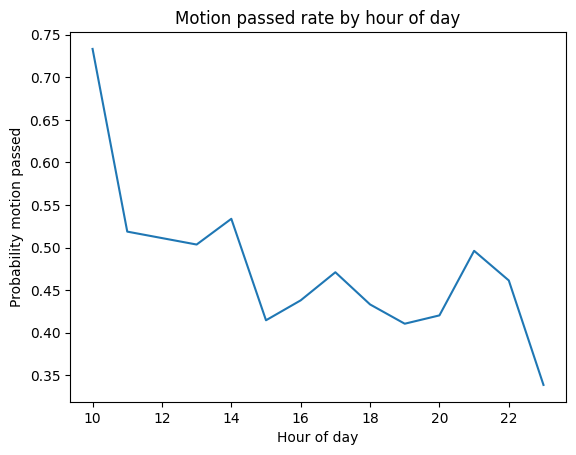

In [103]:
import matplotlib.pyplot as plt

model_df["speech_begin"] = pd.to_datetime(model_df["speech_begin"], errors="coerce")

model_df.groupby("hour_of_day")["motion_passed"].mean().plot()
plt.xlabel("Hour of day")
plt.ylabel("Probability motion passed")
plt.title("Motion passed rate by hour of day")
plt.show()

In [1]:
import pandas as pd

model_df = pd.read_csv("speeches_modeling.csv")

# use 5000 rows for now
model_df = model_df.sample(5000, random_state=42).reset_index(drop=True)

# shorten texts a lot
model_df["speech_text"] = model_df["speech_text"].fillna("").str.slice(0, 600)

model_df.to_csv("speeches_modeling_5000.csv", index=False)
print(model_df.shape)

(5000, 42)


In [2]:
from transformers import pipeline
import pandas as pd
from pathlib import Path

model_df = pd.read_csv("speeches_modeling_5000.csv")

sentiment_pipe = pipeline(
    "text-classification",
    model="DTAI-KULeuven/robbert-v2-dutch-sentiment",
    tokenizer="DTAI-KULeuven/robbert-v2-dutch-sentiment",
    truncation=True,
    top_k=None,
    device=-1
)

chunk_size = 50
batch_size = 1

all_chunks = []
out_file = Path("speeches_sentiment_partial.csv")

for start in range(0, len(model_df), chunk_size):
    end = min(start + chunk_size, len(model_df))
    chunk = model_df.iloc[start:end].copy()

    print(f"Processing rows {start} to {end - 1}")

    outputs = sentiment_pipe(
        chunk["speech_text"].tolist(),
        batch_size=batch_size
    )

    labels, negs, neus, poss = [], [], [], []

    for out in outputs:
        score_map = {d["label"].lower(): d["score"] for d in out}
        neg = score_map.get("negative", 0.0)
        neu = score_map.get("neutral", 0.0)
        pos = score_map.get("positive", 0.0)

        label = max(
            [("negative", neg), ("neutral", neu), ("positive", pos)],
            key=lambda x: x[1]
        )[0]

        labels.append(label)
        negs.append(neg)
        neus.append(neu)
        poss.append(pos)

    chunk["sentiment_label"] = labels
    chunk["sentiment_score_neg"] = negs
    chunk["sentiment_score_neu"] = neus
    chunk["sentiment_score_pos"] = poss

    all_chunks.append(chunk)
    pd.concat(all_chunks, ignore_index=True).to_csv(out_file, index=False)

final_df = pd.concat(all_chunks, ignore_index=True)
final_df.to_csv("speeches_sentiment_5000.csv", index=False)
print(final_df.shape)

c:\Users\Dan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu


Processing rows 0 to 49
Processing rows 50 to 99
Processing rows 100 to 149
Processing rows 150 to 199
Processing rows 200 to 249
Processing rows 250 to 299
Processing rows 300 to 349
Processing rows 350 to 399
Processing rows 400 to 449
Processing rows 450 to 499
Processing rows 500 to 549
Processing rows 550 to 599
Processing rows 600 to 649
Processing rows 650 to 699
Processing rows 700 to 749
Processing rows 750 to 799
Processing rows 800 to 849
Processing rows 850 to 899
Processing rows 900 to 949
Processing rows 950 to 999
Processing rows 1000 to 1049
Processing rows 1050 to 1099
Processing rows 1100 to 1149
Processing rows 1150 to 1199
Processing rows 1200 to 1249
Processing rows 1250 to 1299
Processing rows 1300 to 1349
Processing rows 1350 to 1399
Processing rows 1400 to 1449
Processing rows 1450 to 1499
Processing rows 1500 to 1549
Processing rows 1550 to 1599
Processing rows 1600 to 1649
Processing rows 1650 to 1699
Processing rows 1700 to 1749
Processing rows 1750 to 1799
P

In [4]:
df = pd.read_csv('speeches_sentiment_5000.csv')
print(df.shape)
print(df['motion_passed'].value_counts())
print(df['sentiment_label'].value_counts())

(5000, 46)
motion_passed
1    2522
0    2478
Name: count, dtype: int64
sentiment_label
positive    3129
negative    1871
Name: count, dtype: int64


In [5]:
df.groupby('sentiment_label')['motion_passed'].mean()


sentiment_label
negative    0.463389
positive    0.528923
Name: motion_passed, dtype: float64

In [6]:
df.groupby(['time_bin', 'sentiment_label'])['motion_passed'].mean()

time_bin   sentiment_label
afternoon  negative           0.489342
           positive           0.541284
evening    negative           0.417034
           positive           0.441327
morning    negative           0.495495
           positive           0.543478
Name: motion_passed, dtype: float64